# Simulating 150,000 Tee Jumping Games with Python

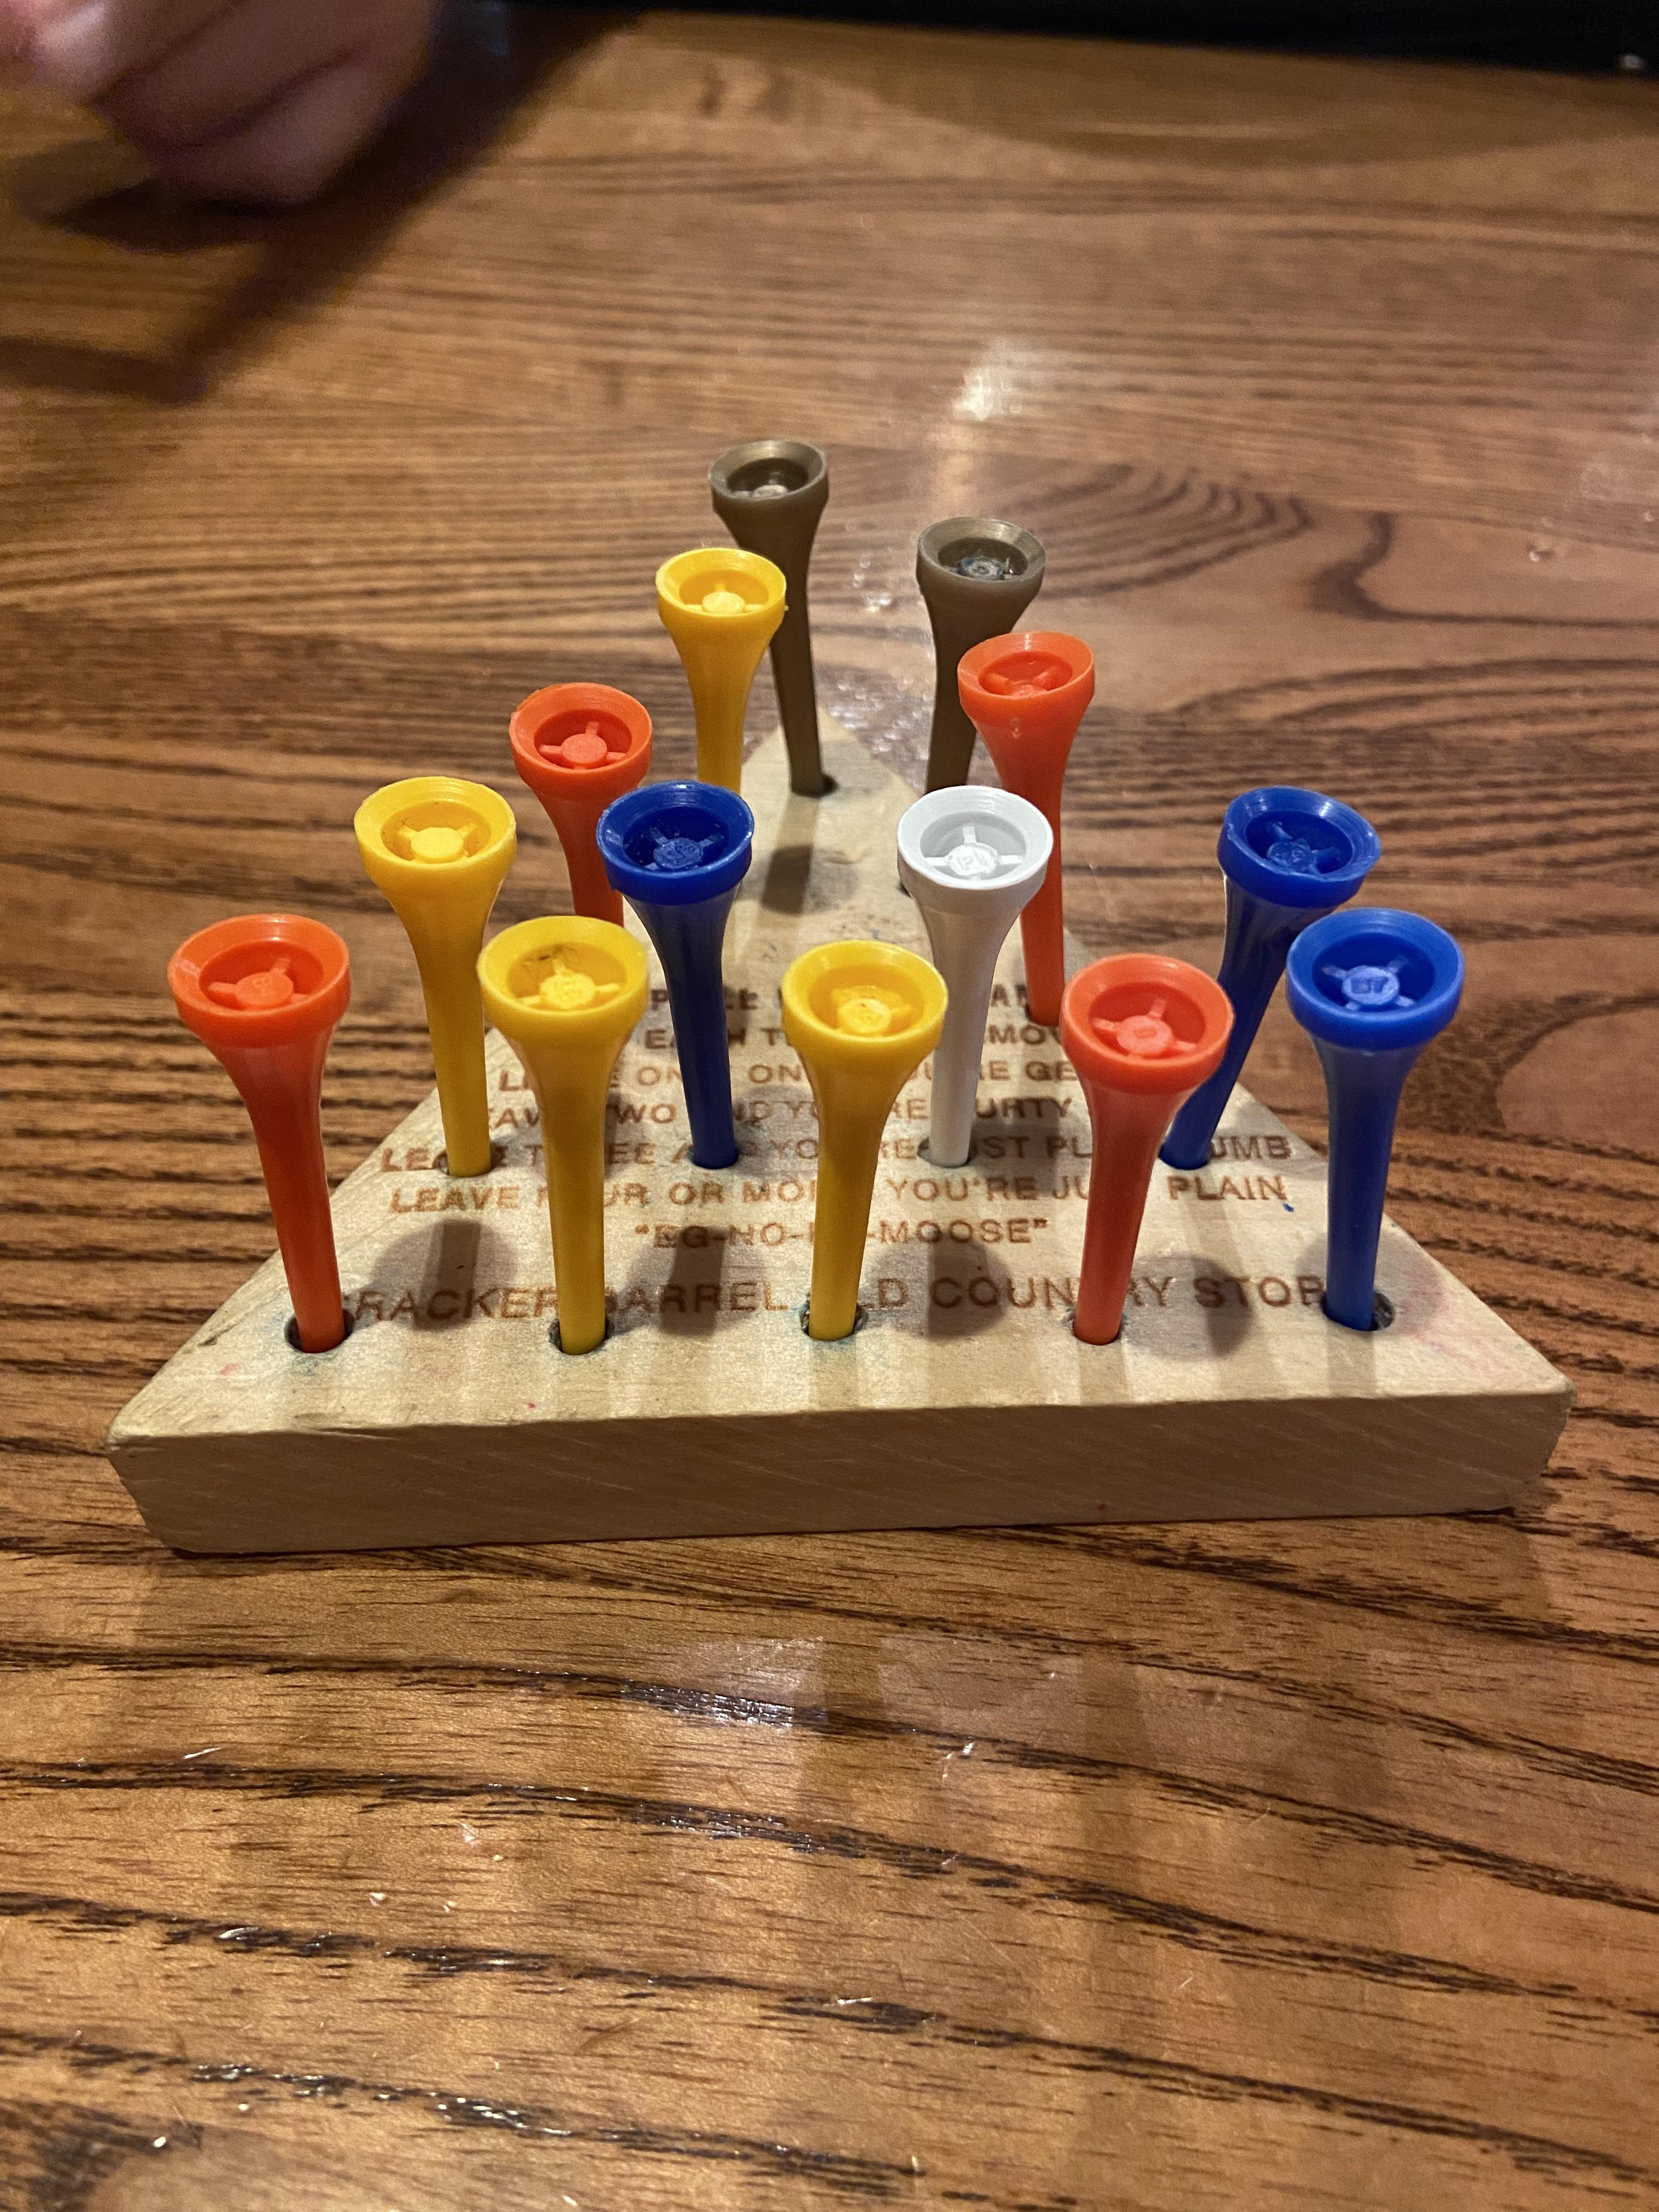

In [14]:
from IPython.display import Image, display
display(Image("Images/Tee_Jumping_Image.jpg", width = 400))

## Rules of the Game:

The player begins by inserting 14 tees into any of the 15 holes, leaving one hole empty. There are of course 15 choices as to which hole to be left empty (These 15 different options will later be referred to as the different "starting layouts"). The player then proceeds by making an available move. A move constitutes one tee jumping over an immediately adjacent tee into the empty hole directly beyond it. The path of this first tee must be in a completely straight line. The tee that was jumped over gets removed from the board (think "draughts" style). The goal is to continue to play moves for as long as possible. With every move that is played of course, the number of tees on the board decreases by 1. You are said to "win" the game if moves can be played until only 1 tee remains in the board.

## Questions:

Is it definitely possible to win the game, i.e to be left with only 1 tee in the triangle? If so, how likely is it to win if playing random moves, without a strategy? Is it possible to win from all 15 choices of starting layouts? Which of the starting layouts if any give a higher likelihood of winning?

## Method:

In [15]:
import numpy as np
rng = np.random.default_rng(seed = 314664530926794984889803001864803463336) #genearated a random 128 bit number using secrets.randbits(128)
import pandas as pd
import time
import matplotlib.pyplot as plt
plt.style.use("ggplot")
%matplotlib inline

Let's begin by labelling the holes with the numbers 1 to 15, as can be seen in the following picture. In this picture, hole number 1 is chosen to be empty. This can be thought of as "starting layout 1"

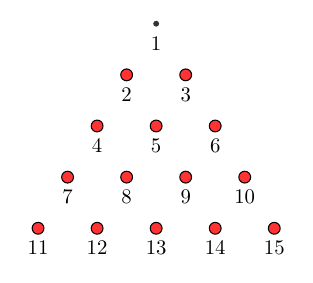

In [16]:
display(Image("Images/Board_Labeled.png"))

### Function to Setup the Board and Defining the Moves:

Create a function that sets up the board. The function takes an integer between 1 and 15 as input, which corresponds to the hole to be left empty.

In [17]:
def set_up(i):
    current_state = [x for x in range(1,16)]
    current_state.remove(i)
    return current_state

Create a list that contains all the moves that are possible in any game, where each move is encoded as a tuple with 3 entries. The tuple (x,y,z) is encoding a tee in position x jumping over a tee in position y into position z. This is done by manually defining half of the moves. The other half being the reverse of these moves, then combining the results.

In [18]:
half_all_moves = [(4,5,6),(7,8,9),(8,9,10),(11,12,13),(12,13,14),(13,14,15),(1,2,4),(2,4,7),(4,7,11),(3,5,8),(5,8,12),(6,9,13),(1,3,6),(3,6,10),(6,10,15),(2,5,9),(5,9,14),(4,8,13)]

rev_half_all_moves = []

for m in half_all_moves:
    m_rev = tuple(reversed(m))
    rev_half_all_moves.append(m_rev)

all_moves = half_all_moves + rev_half_all_moves

print(all_moves)

[(4, 5, 6), (7, 8, 9), (8, 9, 10), (11, 12, 13), (12, 13, 14), (13, 14, 15), (1, 2, 4), (2, 4, 7), (4, 7, 11), (3, 5, 8), (5, 8, 12), (6, 9, 13), (1, 3, 6), (3, 6, 10), (6, 10, 15), (2, 5, 9), (5, 9, 14), (4, 8, 13), (6, 5, 4), (9, 8, 7), (10, 9, 8), (13, 12, 11), (14, 13, 12), (15, 14, 13), (4, 2, 1), (7, 4, 2), (11, 7, 4), (8, 5, 3), (12, 8, 5), (13, 9, 6), (6, 3, 1), (10, 6, 3), (15, 10, 6), (9, 5, 2), (14, 9, 5), (13, 8, 4)]


### Function to Calculate Available Moves:

Create a function that takes any possible layout of tees in the triangle, and returns a list of available moves based on the layout.

In [19]:
def possibilities(current_state):
    avail_moves = []
    for m in all_moves:
        if ({m[0],m[1]}.issubset(current_state) and m[2] not in current_state):
            avail_moves.append(m)
    return avail_moves

### Function to Execute a Move:

Create a function that takes as input any layout of tees, and one available move that can be made, and performs this move in the game.

In [20]:
def perform(current_state, move):
    current_state.remove(move[0])
    current_state.remove(move[1])
    current_state.append(move[2])
    return current_state

### Function to Play the Game:

Now create a function which plays a full game. It takes an integer as input, corresponding to the choice of empty hole when starting the game (the starting layout), and plays in a completely random way. That is, all available moves are calculated at every step, and one is chosen to be performed uniformly at random. This repeats until there are no possible moves left. The function then returns the final layout of the board, and a list of all moves performed:

In [21]:
def play_game(i):

    current_state = set_up(i)
    
    #Start by calculating which moves are available. Game is played as long as moves are available:

    avail_moves = possibilities(current_state)
    moves_played = []
    while len(avail_moves) >= 1:
        
        # Choose an available move uniformly at random. Record that move and perform it. 
        
        choice = avail_moves[rng.integers(low = 0, high = len(avail_moves))]
        current_state = perform(current_state, choice)
        moves_played.append(choice)
        avail_moves = possibilities(current_state)

    return current_state, moves_played

## Playing 150,000 Games:

10,000 games can now be played completely randomly for each of the 15 starting layouts. A timer will record how long it takes to do this (approx. 30 seconds):

In [22]:
start_time = time.time()

all_results_data = []

for i in range(1,16):
    for j in range(10000):
        result = play_game(i)
        data_row = [i, len(result[0]), result[0], result[1]]
        all_results_data.append(data_row)
        
print("-----%s seconds-----" % (time.time() - start_time))

-----31.968693494796753 seconds-----


## Analyzing the Results:

Let's put all the outcomes into a pandas DataFrame and look at the first 20 rows:

In [23]:
df_results = pd.DataFrame(all_results_data, columns = ["Starting Layout", "# Tees Remaining", "End Layout", "Moves Played"])

print(df_results.head(20))

    Starting Layout  # Tees Remaining                End Layout  \
0                 1                 3               [4, 15, 13]   
1                 1                 4            [15, 6, 12, 4]   
2                 1                 3                [3, 4, 13]   
3                 1                 4             [13, 6, 1, 4]   
4                 1                 4            [6, 1, 15, 13]   
5                 1                 3               [11, 13, 6]   
6                 1                 4             [6, 1, 4, 13]   
7                 1                 4           [11, 13, 10, 4]   
8                 1                 4             [13, 4, 1, 6]   
9                 1                 7  [2, 7, 11, 1, 4, 13, 15]   
10                1                 4           [10, 13, 11, 4]   
11                1                 4            [1, 6, 15, 13]   
12                1                 6       [7, 11, 1, 4, 2, 6]   
13                1                 6      [9, 1, 13, 15, 6, 4

The first thing to look at is the column containing the number of tees remaining in each game. Let's group the games based on how many tees they left in the board, and count how many of each there were.

In [24]:
total_dist = df_results["# Tees Remaining"].value_counts().sort_index()
print(total_dist)

# Tees Remaining
1       632
2      7237
3     34768
4     71886
5     25131
6      6325
7      3354
8        23
10      644
Name: count, dtype: int64


We can see that there were 632 successful games, so it is possible to win! However this number is only approximately 0.004213% of the total amount of games played, so you should expect to win after 238 games. It is also noteworthy that only 23 out of the 150,000 games left 8 tees on the board, and no games left exactly 9, or more than 10 tees.

Let's plot this distribution using a bar chart:

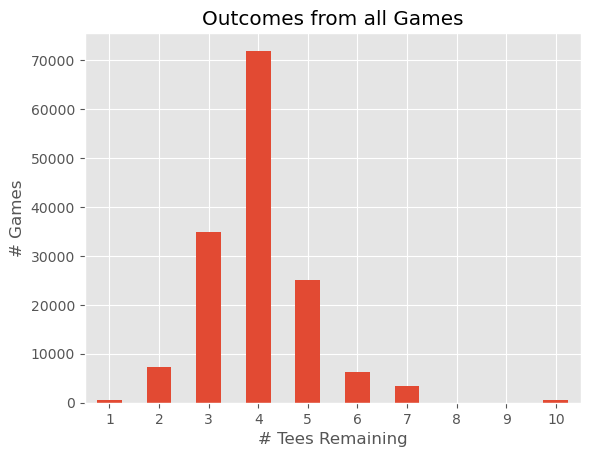

In [27]:
# First fill in the missing 9 value, so the x axis of the plot is not misleading

full_index = range(1,11)
total_dist_full = total_dist.reindex(full_index, fill_value = 0)

total_dist_full.plot(kind = "bar")
plt.title("Outcomes from all Games")
plt.xticks(rotation = 0)
plt.ylabel("# Games")
plt.savefig("Outputs/Outcomes_all_games.png")
plt.show()

Now let's answer the following two questions:

1. Is it possible to win from any starting position?
2. Which starting position gives the greatest chance of winning, when playing uniformly at random?

To answer these, let's group all results by starting layout, and plot the distribution of outcomes in each case.

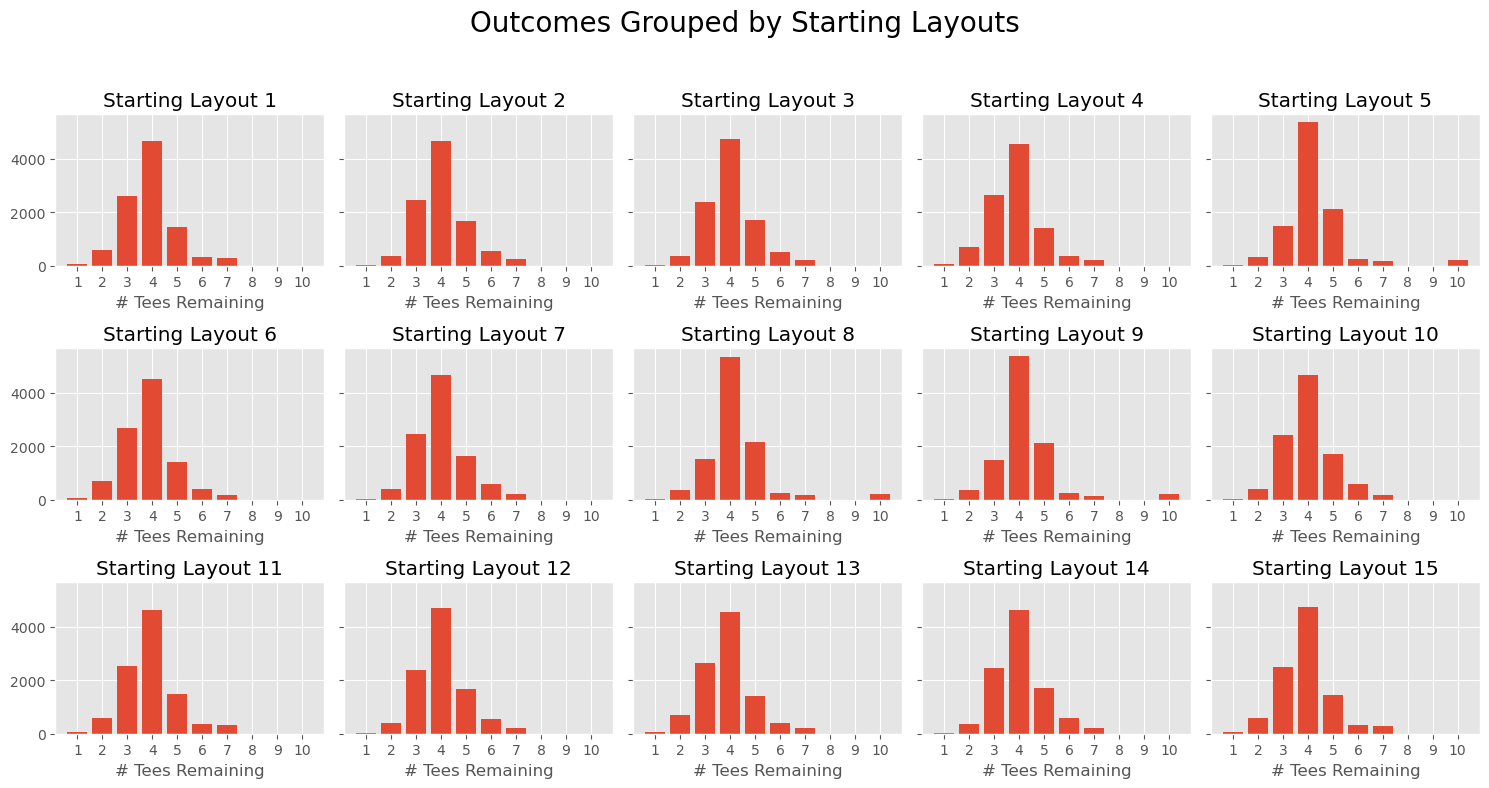

In [28]:
grouped_df_results = df_results.groupby("Starting Layout")["# Tees Remaining"].value_counts().sort_index()
list_group_results = []

for i in range(15):
    list_group_results.append(grouped_df_results.loc[[i+1]].droplevel(0).reindex(full_index, fill_value = 0))

fig, axs = plt.subplots(3,5, figsize = (15,8), sharey = True)
axs = axs.flatten()
fig.suptitle("Outcomes Grouped by Starting Layouts", fontsize = 20)

for i in range(15):
    axs[i].bar(list_group_results[i].index, list_group_results[i].values)
    axs[i].set_title("Starting Layout " + str(i+1))
    axs[i].set_xlabel("# Tees Remaining")
    axs[i].set_xticks(range(1,11))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("Outputs/Outcomes_Grouped.png")
plt.show()

It is quite hard to visually compare all 15 of these distributions, so let's calculate how many winners there were in each case, and calculate what this means in terms of likelihood to win.

In [29]:
wins_grouped = []

for i in range(15):
    wins_grouped.append(list_group_results[i][1])

df_wins_grouped = pd.DataFrame({"# of wins": wins_grouped}, index = range(1,16)).rename_axis("Starting Layout")
df_wins_grouped["Chance of winning (%)"] = df_wins_grouped["# of wins"]/100 # Divide by 10000 games, multiply by 100 to get a percentage
df_wins_grouped["Expected number of games to win"] = np.ceil((10000/df_wins_grouped["# of wins"]))

print(df_wins_grouped)

                 # of wins  Chance of winning (%)  \
Starting Layout                                     
1                       60                   0.60   
2                       29                   0.29   
3                       35                   0.35   
4                       69                   0.69   
5                       16                   0.16   
6                       62                   0.62   
7                       34                   0.34   
8                       14                   0.14   
9                       11                   0.11   
10                      28                   0.28   
11                      68                   0.68   
12                      37                   0.37   
13                      72                   0.72   
14                      39                   0.39   
15                      58                   0.58   

                 Expected number of games to win  
Starting Layout                                

We see that there are indeed wins for all starting layouts. In these 150,000 simulated games, starting with hole number 13 being empty lead to the most amount of wins at 72. This is still only a 0.72% chance of winning with an expected 139 games to be played before a win. By symmetries of the triangle of course, we should expect the result to be the exact same for holes 4 and 6.

## Symmetries in the Results:

In fact, consider the following partition of the 15 starting layouts:

Group 1 = {1,11,15}

Group 2 = {2,3,7,10,12,14}

Group 3 = {4,6,13}

Group 4 = {5,8,9}

Let's create a diagram to display this partition using different colours.

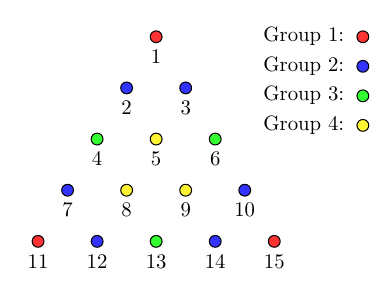

In [30]:
display(Image("Images/Symmetry_Groups.png"))

By rotational and reflective symmetry of the triangle, should expect the distribution of the outcomes to be identical across every starting layout in the same group.

Group the 15 calculated chances of winning according to this partition. Are they similar in each group?

In [31]:
group_1 = df_wins_grouped.loc[[1,11,15]]["Chance of winning (%)"]
group_2 = df_wins_grouped.loc[[2,3,7,10,12,14]]["Chance of winning (%)"]
group_3 = df_wins_grouped.loc[[4,6,13]]["Chance of winning (%)"]
group_4 = df_wins_grouped.loc[[5,8,9]]["Chance of winning (%)"]

print(group_1, group_2, group_3, group_4)

Starting Layout
1     0.60
11    0.68
15    0.58
Name: Chance of winning (%), dtype: float64 Starting Layout
2     0.29
3     0.35
7     0.34
10    0.28
12    0.37
14    0.39
Name: Chance of winning (%), dtype: float64 Starting Layout
4     0.69
6     0.62
13    0.72
Name: Chance of winning (%), dtype: float64 Starting Layout
5    0.16
8    0.14
9    0.11
Name: Chance of winning (%), dtype: float64


The numbers in each group do indeed appear to be similar. It is hard to differentiate between Group 1 and Group 3, both appear to have likelihoods of winning of approximately 0.6-0.7%. But it seems to be clear (at least from these 150,000 simulated games), that Group 4 has the worse odds of winning at around 0.15%, with Group 2 not much better at about 0.3%.

Let's create a visual of these results and how they relate to the starting layouts, followed by a colour-coded bar plot of the results.

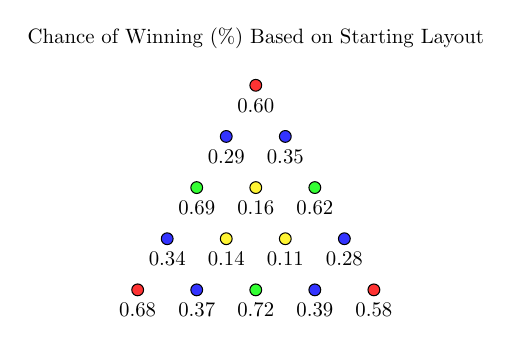

In [32]:
display(Image("Images/Outcomes.png"))

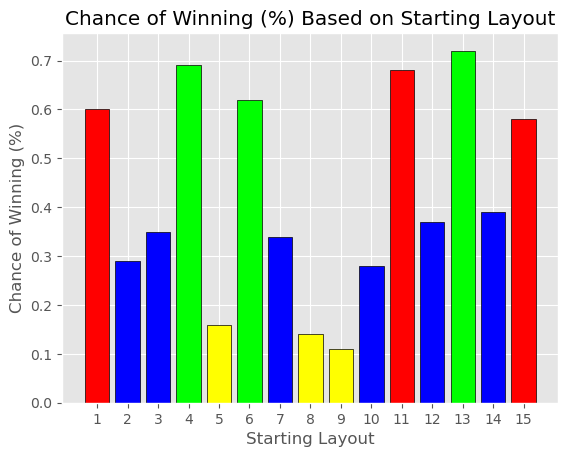

In [34]:
plt.bar(df_wins_grouped.index, height = df_wins_grouped["Chance of winning (%)"], color = ["red","blue","blue","lime","yellow","lime","blue","yellow","yellow","blue","red","blue","lime","blue","red"], edgecolor = "black")
plt.xticks(df_wins_grouped.index)
plt.title("Chance of Winning (%) Based on Starting Layout")
plt.xlabel("Starting Layout")
plt.ylabel("Chance of Winning (%)")
plt.savefig("Outputs/Chance_of_Winning.png")
plt.show()

### Final Results

This final bar chart visually displays the final results, with the colours identifying starting layouts which should have identical chances of winning, based on symmetries of the board. It is clear that starting layouts 1, 4, 6, 11, 13 and 15 (the red and green) give much higher chances of winning than the rest!